# Create Quantum Circuits

### References
- https://quantum.cloud.ibm.com/docs/en/guides/classical-feedforward-and-control-flow
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.Parameter
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.ParameterExpression
- https://quantum.cloud.ibm.com/docs/en/guides/transpiler-stages
- https://quantum.cloud.ibm.com/docs/en/guides/transpile-with-pass-managers
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_passes
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit
- https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits
- https://quantum.cloud.ibm.com/docs/en/guides/circuit-library
- https://quantum.cloud.ibm.com/docs/en/guides/transpile
- https://quantum.cloud.ibm.com/docs/en/guides/intro-to-patterns
- https://quantum.cloud.ibm.com/docs/en/guides/set-optimization

## Dynamic Circuits

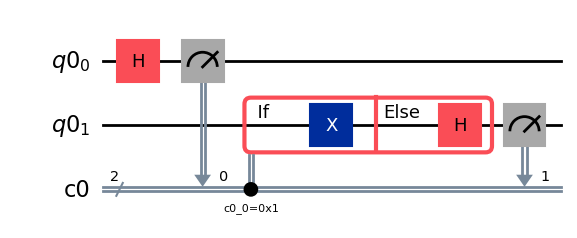

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc = QuantumCircuit(qr,cr)
(q0,q1) = qr
(c0, c1) = cr

qc.h(q0)
qc.measure(q0,c0)

with qc.if_test((c0,1)) as else_block:
    qc.x(q1)
with else_block:
    qc.h(q1)

qc.measure(q1,c1)
qc.draw("mpl")

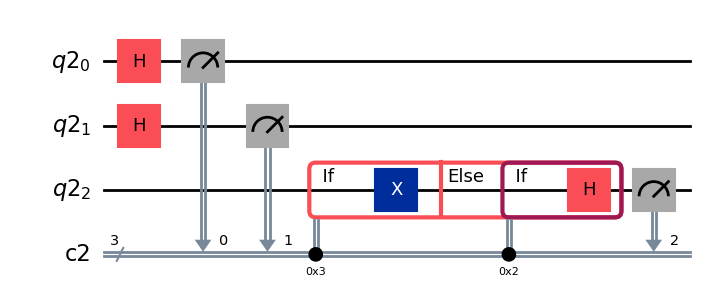

In [5]:
qubits = QuantumRegister(3)
clbits = ClassicalRegister(3)
qc = QuantumCircuit(qubits, clbits)
(q0,q1,q2) = qubits
(c0,c1,c2) = clbits

qc.h([q0,q1])
qc.measure([q0,q1], [c0,c1])

with qc.if_test((clbits, 0b011)) as else_block:
    qc.x(q2)
with else_block:
    with qc.if_test((clbits, 0b010)):
        qc.h(q2)
        
qc.measure(q2,c2)
qc.draw("mpl")

## Classical Expressions

Classical Expressions allow you to perform logic (like AND, OR, NOT, and bitwise comparisons) on classical bits or registers directly within the circuit.

Instead of just checking if a bit is 0 or 1, expressions allow you to trigger gates based on complex conditions, like "If Bit A is 1 AND Bit B is 0."

Dynamic Logic: These are evaluated at runtime on the actual quantum hardware (or a simulator that supports dynamic circuits).

**lift** converts the register into a type that Qiskit’s expression engine recognizes, allowing it to be treated like a variable in an equation.

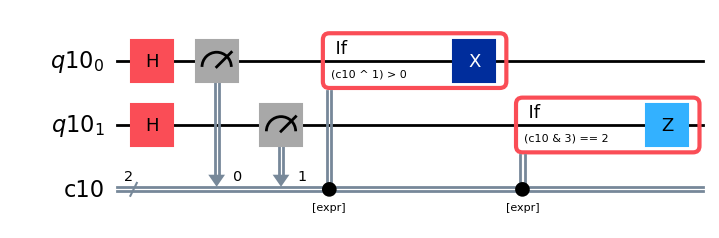

In [13]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import classical

qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc = QuantumCircuit(qr, cr)

qc.h([0, 1])
qc.measure(qr, cr)

# Lift the register
reg_expr = classical.expr.lift(cr)

# 1. Bitwise XOR AND THEN compare to a value to get a 'Bool'
# This says: "Is the result of (reg ^ 1) greater than 0?"
condition_xor = classical.expr.greater(classical.expr.bit_xor(reg_expr, 1), 0)

# 2. Bitwise AND AND THEN compare to a value to get a 'Bool'
# This says: "Is the result of (reg & 2) equal to 2?"
condition_and = classical.expr.equal(classical.expr.bit_and(reg_expr, 3), 2)

# Now if_test will work because the conditions are 'Bool'
with qc.if_test(condition_xor):
    qc.x(0)

with qc.if_test(condition_and):
    qc.z(1)

qc.draw("mpl")

### Logic Execution Table

| Measurement Outcome (`cr`) | Condition 1: `(reg ^ 1) > 0` | Gate `X(0)` | Condition 2: `(reg & 2) == 2` | Gate `Z(1)` |
| :--- | :--- | :--- | :--- | :--- |
| **0** (binary `00`) | `(0 ^ 1) = 1` (**True**) | **Runs** | `(0 & 2) = 0` (**False**) | Stays Idle |
| **1** (binary `01`) | `(1 ^ 1) = 0` (**False**) | Stays Idle | `(1 & 2) = 0` (**False**) | Stays Idle |
| **2** (binary `10`) | `(2 ^ 1) = 3` (**True**) | **Runs** | `(2 & 2) = 2` (**True**) | **Runs** |
| **3** (binary `11`) | `(3 ^ 1) = 2` (**True**) | **Runs** | `(3 & 2) = 2` (**True**) | **Runs** |

**Note:** The binary values represent the state of the classical register `c5` immediately after the measurement gates.

## Parameter

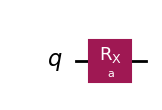

In [17]:
from qiskit.circuit import Parameter

qc = QuantumCircuit(1)
phi = Parameter("a")

qc.rx(phi, 0)
qc.draw("mpl")

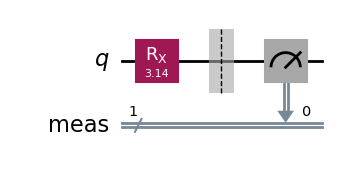

In [18]:
# bind the parameters after circuit to create a bound circuit
bc = qc.assign_parameters({phi: 3.14})
bc.measure_all()
bc.draw("mpl")

In [19]:
phi.name

'a'

In [23]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
print(circuit.global_phase)

0.0


In [24]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2, name="my_circuit")
print(qc.name)

my_circuit


In [25]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2, metadata={'experiment_type': 'Bell state experiment'})

print(qc.metadata)

{'experiment_type': 'Bell state experiment'}


In [26]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qr1 = QuantumRegister(2)
qr2 = QuantumRegister(1)
cr1 = ClassicalRegister(2)
cr2 = ClassicalRegister(1)
qc = QuantumCircuit(qr1, qr2, cr1, cr2)

print("List the qubits in this circuit:", qc.qubits)
print("List the classical bits in this circuit:", qc.clbits)

List the qubits in this circuit: [<Qubit register=(2, "q11"), index=0>, <Qubit register=(2, "q11"), index=1>, <Qubit register=(1, "q12"), index=0>]
List the classical bits in this circuit: [<Clbit register=(2, "c11"), index=0>, <Clbit register=(2, "c11"), index=1>, <Clbit register=(1, "c12"), index=0>]


In [30]:
>>> from qiskit.circuit import QuantumCircuit, Parameter
>>> a, b, elephant = Parameter("a"), Parameter("b"), Parameter("elephant")
>>> circuit = QuantumCircuit(1)
>>> circuit.rx(b, 0)
>>> circuit.rz(elephant, 0)
>>> circuit.ry(a, 0)
>>> circuit.parameters  # sorted alphabetically!

ParameterView([Parameter(a), Parameter(b), Parameter(elephant)])

In [31]:
>>> from qiskit.circuit import QuantumCircuit, Parameter
>>> angles = [Parameter("angle_1"), Parameter("angle_2"), Parameter("angle_10")]
>>> circuit = QuantumCircuit(1)
>>> circuit.u(*angles, 0)
>>> circuit.draw()

┌─────────────────────────────┐
q: ┤ U(angle_1,angle_2,angle_10) ├
   └─────────────────────────────┘

In [32]:
>>> circuit.parameters

ParameterView([Parameter(angle_1), Parameter(angle_10), Parameter(angle_2)])

In [34]:
# To respect numerical sorting, a ParameterVector can be used

from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
x = ParameterVector("x", 12)
circuit = QuantumCircuit(1)
for x_i in x:
    circuit.rx(x_i, 0)
circuit.parameters

ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3]), ParameterVectorElement(x[4]), ParameterVectorElement(x[5]), ParameterVectorElement(x[6]), ParameterVectorElement(x[7]), ParameterVectorElement(x[8]), ParameterVectorElement(x[9]), ParameterVectorElement(x[10]), ParameterVectorElement(x[11])])

In [35]:
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister

# Create a 2-qubit quantum circuit
reg = QuantumRegister(2)
qc = QuantumCircuit(reg)

# Create an ancilla register with 1 qubit
anc = AncillaRegister(1)
qc.add_register(anc)  # Add the ancilla register to the circuit

print("Number of ancilla qubits:", qc.num_ancillas)

Number of ancilla qubits: 1


In [36]:
from qiskit.circuit import QuantumCircuit, Duration
from qiskit.circuit.classical import expr

qc = QuantumCircuit(2)
my_stretch = qc.add_stretch("my_stretch")

qc.delay(expr.add(Duration.dt(200), my_stretch), 1)

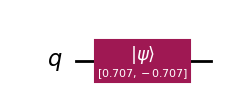

In [37]:
import numpy as np
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)
circuit.initialize([1/np.sqrt(2), -1/np.sqrt(2)], 0)
circuit.draw("mpl")

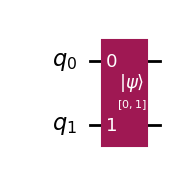

In [38]:
import numpy as np
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2)
circuit.initialize('01', circuit.qubits)
circuit.draw("mpl")

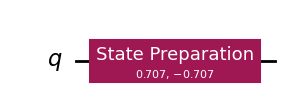

In [39]:
import numpy as np
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)
circuit.prepare_state([1/np.sqrt(2), -1/np.sqrt(2)], 0)
circuit.draw("mpl")

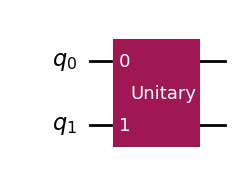

In [41]:
from qiskit import QuantumCircuit
matrix = [[0, 0, 0, 1],
        [0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0]]
circuit = QuantumCircuit(2)
circuit.unitary(matrix, [0, 1])
circuit.draw("mpl")

In [42]:
from qiskit.circuit import QuantumCircuit, Annotation

class MyAnnotation(Annotation):
    namespace = "my.namespace"

qc = QuantumCircuit(9)
with qc.box():
    qc.cz(0, 1)
    qc.cz(2, 3)
with qc.box([MyAnnotation()]):
    qc.cz(4, 5)
    qc.cz(6, 7)
    qc.noop(8)

Using the builder interface to add two boxes in sequence. The two boxes in this circuit can execute concurrently, and the second explicitly inserts a data-flow dependency on qubit 8 for the duration of the box, even though the qubit is idle.

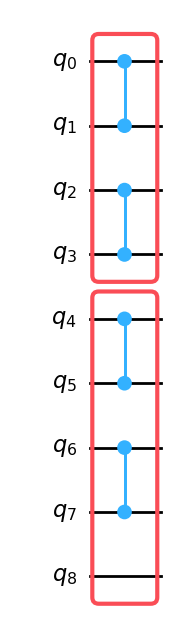

In [43]:
qc.draw("mpl")

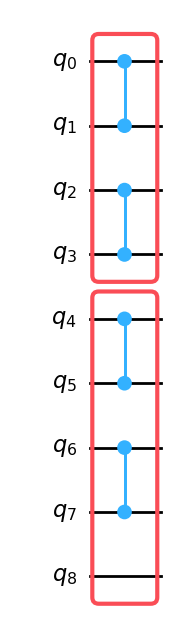

In [45]:
from qiskit.circuit import QuantumCircuit, BoxOp

body_0 = QuantumCircuit(4)
body_0.cz(0, 1)
body_0.cz(2, 3)

# Note that the qubit indices inside a body related only to the body.  The
# association with qubits in the containing circuit is made by the ``qubits``
# argument to `QuantumCircuit.box`.
body_1 = QuantumCircuit(5)
body_1.cz(0, 1)
body_1.cz(2, 3)

qc = QuantumCircuit(9)
qc.box(body_0, [0, 1, 2, 3], [])
qc.box(body_1, [4, 5, 6, 7, 8], [])

qc.draw("mpl")

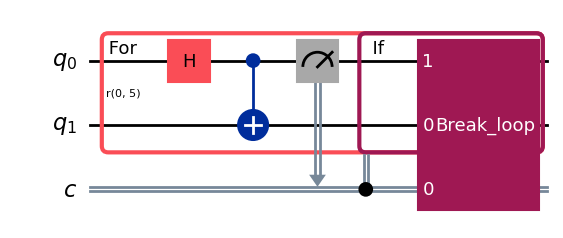

In [48]:
qc = QuantumCircuit(2,1)

with qc.for_loop(range(5)) as i:
    qc.h(0)
    qc.cx(0, 1)
    qc.measure(0, 0)
    with qc.if_test((0, True)):
        qc.break_loop()
qc.draw("mpl")

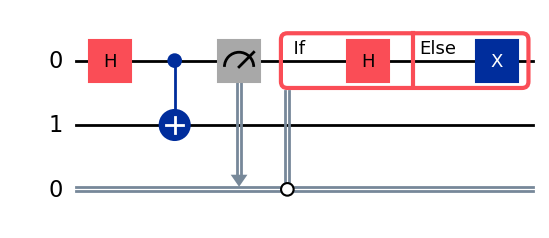

In [49]:
from qiskit.circuit import QuantumCircuit, Qubit, Clbit
bits = [Qubit(), Qubit(), Clbit()]
qc = QuantumCircuit(bits)
qc.h(0)
qc.cx(0, 1)
qc.measure(0, 0)
with qc.if_test((bits[2], 0)) as else_:
    qc.h(0)
with else_:
    qc.x(0)
qc.draw("mpl")

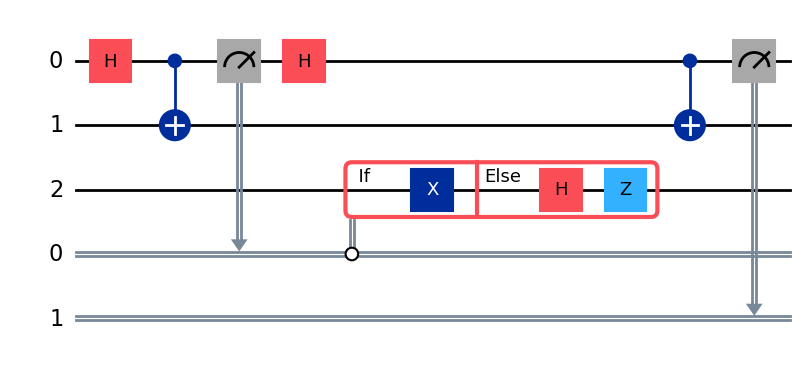

In [50]:
from qiskit.circuit import QuantumCircuit, Qubit, Clbit
bits = [Qubit(), Qubit(), Qubit(), Clbit(), Clbit()]
qc = QuantumCircuit(bits)

qc.h(0)
qc.cx(0, 1)
qc.measure(0, 0)
qc.h(0)
qc.cx(0, 1)
qc.measure(0, 1)

with qc.if_test((bits[3], 0)) as else_:
    qc.x(2)
with else_:
    qc.h(2)
    qc.z(2)
qc.draw("mpl")

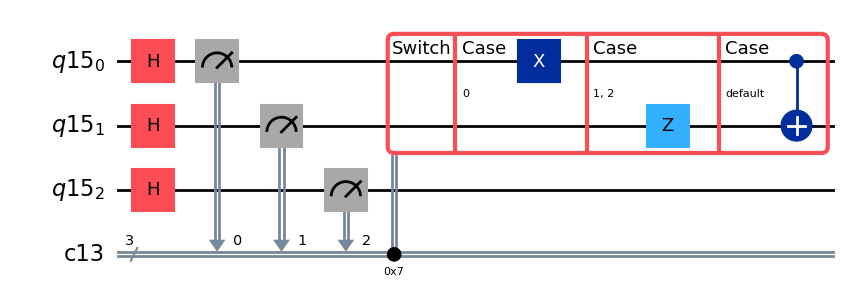

In [51]:
from qiskit.circuit import QuantumCircuit, ClassicalRegister, QuantumRegister
qreg = QuantumRegister(3)
creg = ClassicalRegister(3)
qc = QuantumCircuit(qreg, creg)
qc.h([0, 1, 2])
qc.measure([0, 1, 2], [0, 1, 2])

with qc.switch(creg) as case:
    with case(0):
        qc.x(0)
    with case(1, 2):
        qc.z(1)
    with case(case.DEFAULT):
        qc.cx(0, 1)
qc.draw("mpl")

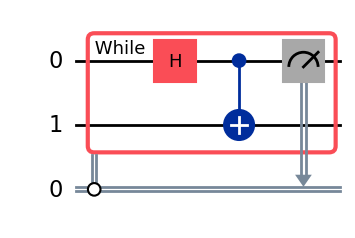

In [53]:
from qiskit.circuit import QuantumCircuit, Clbit, Qubit
bits = [Qubit(), Qubit(), Clbit()]
qc = QuantumCircuit(bits)

with qc.while_loop((bits[2], 0)):
    qc.h(0)
    qc.cx(0, 1)
    qc.measure(0, 0)
qc.draw("mpl")

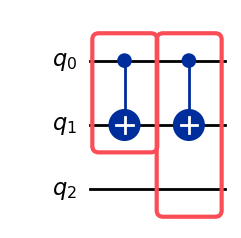

In [54]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(3)
with qc.box():
    # This control-flow block will only use qubits 0 and 1.
    qc.cx(0, 1)
with qc.box():
    # This control-flow block will contain only the same operation as the previous
    # block, but it will also mark qubit 2 as "used" by the box.
    qc.cx(0, 1)
    qc.noop(2)
qc.draw("mpl")

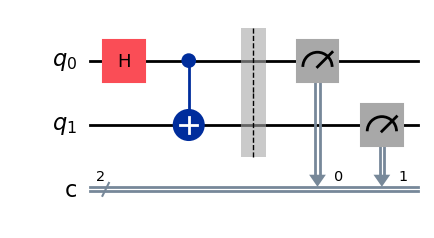

In [55]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.passes import RemoveFinalMeasurements

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()
qc.measure([0, 1], [0, 1])

pass_ = RemoveFinalMeasurements()
just_bell = pass_(qc)
qc.draw("mpl")

The four steps of a Qiskit pattern are as follows:

- Map problem to quantum circuits and operators
- Optimize for target hardware
- Execute on target hardware
- Post-process results

### Map the problem to quantum circuits and operators

This step describes how a user starts with a classical problem and figures out how to map it to a quantum computer. For example, in applications such as chemistry and quantum simulation, this step generally involves constructing a quantum circuit representing the Hamiltonian you are attempting to solve. During this step, for certain problems, it might also be desirable to specify the mapping of the problem onto qubits in the heavy-hex (or gross) lattice of IBM® hardware from the outset if the structure of the problem lends itself to optimization earlier. It is also worth considering at this point what the outcome of the particular algorithm will be in preparation for the later execute step - for example, if the desired outcome involves inferring correlation functions using Hadamard tests, you might prepare to use Sampler, whereas specifying observables would use the Estimator and could provide many error mitigation options.

The output of this step is normally a collection of circuits or quantum operators that can be optimized for hardware in the next step.

### Optimize for target hardware

In this step you take the abstract circuits (or operators) produced from the map step and perform a series of optimizations on them. This can include mapping the route and layout of the circuit to physical qubit hardware, converting to basis gates of the hardware, and reducing the number of operations, all designed to optimize the likelihood of success in the later execute step. At this point you might also wish to test out your circuits with a simulator before executing on real hardware in the next step.

During this step, abstract circuits must be transpiled to Instruction Set Architecture (ISA) circuits. An ISA circuit is one that only consists of gates understood by the target hardware (basis gates), and any multi-qubit gates needed to obey any connectivity constraints (coupling map). Only ISA circuits can be run on IBM hardware using IBM Qiskit Runtime.

### Execute on target hardware

This step involves running your circuits on hardware and produces the outputs of the quantum computation. The ISA circuits produced in the previous step can be executed using either a Sampler or Estimator primitive from Qiskit Runtime, initialized locally on your computer or from a cluster or other heterogeneous compute environment. These can be executed in a Batch, which allows parallel transpilation for classical computational efficiency - or a Session, which allows iterative tasks to be implemented efficiently without queuing delays. During this step, there is also the option to configure certain error suppression and mitigation techniques provided by Qiskit Runtime.

Depending on whether you are using the Sampler or Estimator primitive, the outcome of this step will be different. If using the Sampler, the output will be per-shot measurements in the form of bitstrings. If using the Estimator, the output will be expectation values of observables corresponding to physical quantities or cost functions.

### Post-process results

This final step involves stitching the outputs from the prior step back together to obtain the desired result. This can involve a range of classical data-processing steps such as visualizing results, readout error mitigation techniques, marginalizing quasi-probability distributions to ascertain results on smaller sets of qubits, or post-selection on inherent properties of the problem, such as total spin, parity, or particle conservation by removing unphysical observables.

## Circuit Library

### Standard Gates

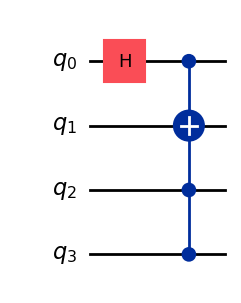

In [59]:
from qiskit.circuit.library import HGate, MCXGate

mcx_gate = MCXGate(3)
h_gate = HGate()

qc = QuantumCircuit(4)
qc.append(h_gate, [0])
qc.append(mcx_gate, [0,3,2,1])
qc.draw("mpl")

### N-local circuits

These circuits alternate layers of single-qubit rotation gates with layers of multi-qubit entangling gates.

This family of circuits is popular in variational quantum algorithms because they can produce a wide range of quantum states. Variational algorithms adjust the gate parameters to find states that have certain properties (such as states that represent a good solution to an optimization problem). For this purpose, many circuits in the library are parameterized, which means you can define them without fixed values.

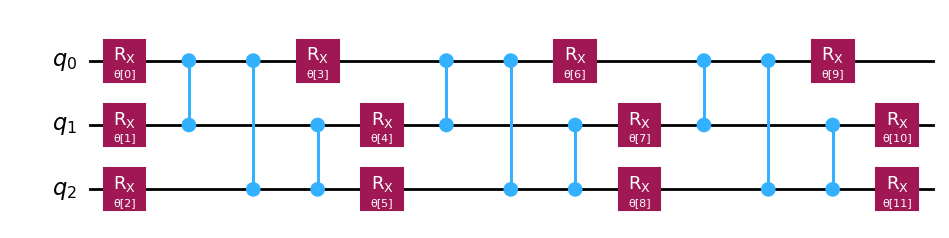

In [61]:
from qiskit.circuit.library import n_local

two_local = n_local(3, "rx", "cz")
two_local.draw("mpl")

In [62]:
two_local.parameters

ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])

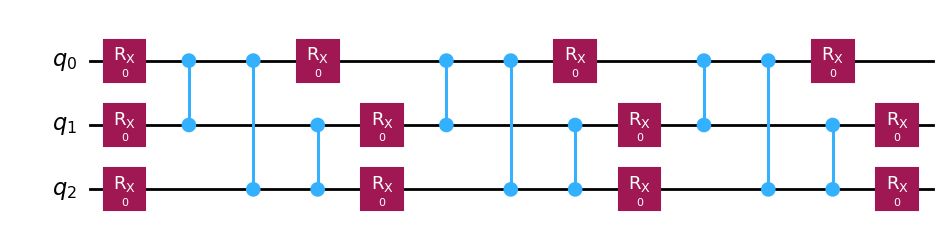

In [64]:
bound_circuit = two_local.assign_parameters(
    {p: 0 for p in two_local.parameters}
)
bound_circuit.draw("mpl")

### Data encoding circuits

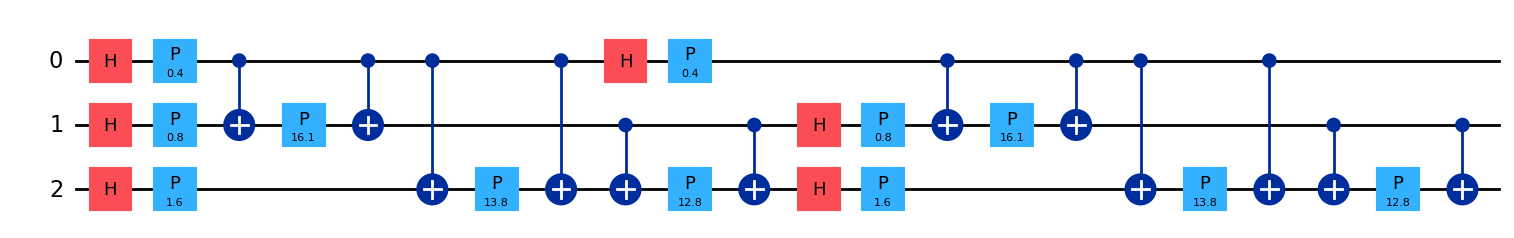

In [67]:
from qiskit.circuit.library import zz_feature_map

features = [0.2, 0.4, 0.8]
feature_map = zz_feature_map(feature_dimension=len(features))

encoded = feature_map.assign_parameters(features)
encoded.draw("mpl")

### Time-evolution circuits

These circuits simulate a quantum state evolving in time. Use time-evolution circuits to investigate physical effects such as heat transfer or phase transitions in a system. Time-evolution circuits are also a fundamental building block of chemistry wave functions (such as unitary coupled-cluster trial states) and of the QAOA algorithm we use for optimization problems.

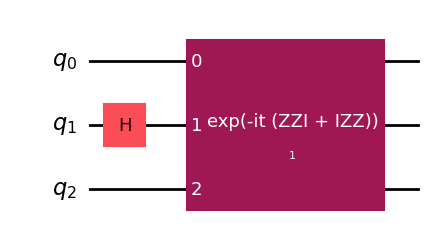

In [68]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp


# Prepare an initial state with a Hadamard on the middle qubit
state = QuantumCircuit(3)
state.h(1)

hamiltonian = SparsePauliOp(["ZZI", "IZZ"])
evolution = PauliEvolutionGate(hamiltonian, time=1)

# Evolve state by appending the evolution gate
state.compose(evolution, inplace=True)

state.draw("mpl")

### Benchmarking and complexity-theory circuits

Benchmarking circuits give us a sense of how well our hardware is actually working, and complexity-theory circuits help us understand how difficult the problems we want to solve are.

Tthe "quantum volume" benchmark measures how accurately a quantum computer executes a type of random quantum circuit. The score of the quantum computer increases with the size of the circuit it can reliably run. This takes into account all aspects of the computer, including qubit count, instruction fidelity, qubit connectivity, and the software stack transpiling and post-processing results

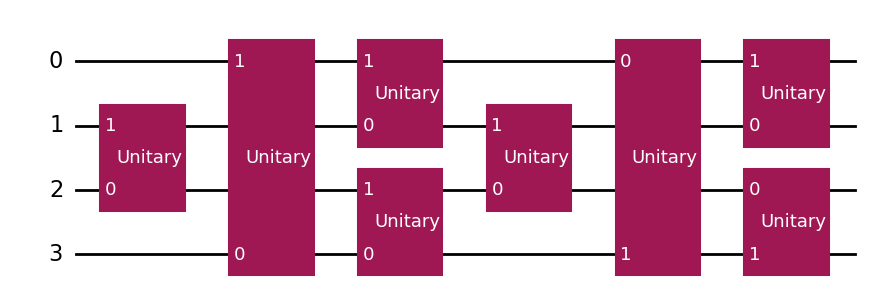

In [69]:
from qiskit.circuit.library import quantum_volume

quantum_volume(4).draw("mpl")

Instructions and circuits are similar in that they both describe operations on bits and qubits, but they have different purposes:

Instructions are treated as fixed, and their methods will usually return new instructions (without mutating the original object).
Circuits are designed to be built over many lines of code, and QuantumCircuit methods often mutate the existing object.

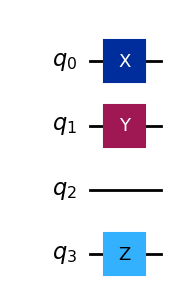

In [70]:
qc_a = QuantumCircuit(4)
qc_a.x(0)

qc_b = QuantumCircuit(2, name="qc_b")
qc_b.y(0)
qc_b.z(1)

# compose qubits (0, 1) of qc_a to qubits (1, 3) of qc_b respectively
combined = qc_a.compose(qc_b, qubits=[1, 3])
combined.draw("mpl")

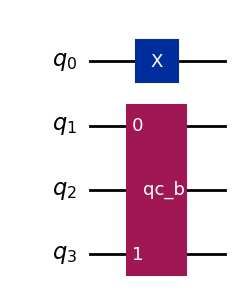

In [71]:
inst = qc_b.to_instruction()
qc_a.append(inst, [1, 3])
qc_a.draw("mpl")

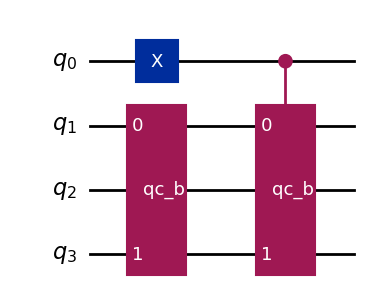

In [72]:
gate = qc_b.to_gate().control()
qc_a.append(gate, [0, 1, 3])
qc_a.draw("mpl")

- QuantumCircuit.measure : measures each qubit in the first argument onto the classical bit given as the second argument. This method allows full control over where the measurement result is stored.

- QuantumCircuit.measure_all : takes no argument and can be used for quantum circuits without pre-defined classical bits. It creates classical wires and stores measurement results in order. It also adds a barrier before the measurement.

- QuantumCircuit.measure_active : similar to measure_all, but measures only qubits that have operations.

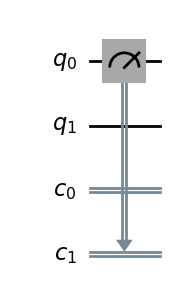

In [73]:
qc1 = QuantumCircuit(2, 2)
qc1.measure(0, 1)
qc1.draw("mpl", cregbundle=False)

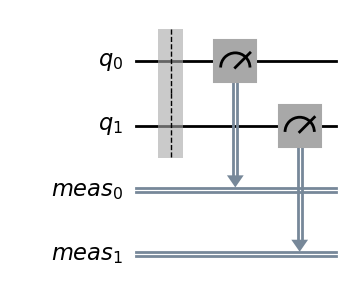

In [74]:
qc2 = QuantumCircuit(2)
qc2.measure_all()
qc2.draw("mpl", cregbundle=False)

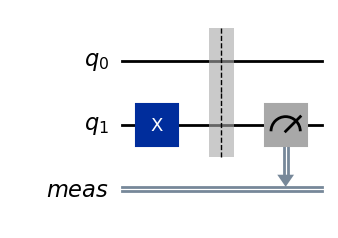

In [75]:
qc3 = QuantumCircuit(2)
qc3.x(1)
qc3.measure_active()
qc3.draw("mpl", cregbundle=False)

In [77]:
from qiskit.circuit.library import z_feature_map
from qiskit.circuit import ParameterVector

# Define a parameterized circuit with default names
# For example, x[0]
circuit = z_feature_map(2)

# Set new parameter names
# They will now be prefixed by `hi` instead
# For example, hi[0]
training_params = ParameterVector("hi", 2)

# Assign parameter names to the quantum circuit
circuit = circuit.assign_parameters(parameters=training_params)
circuit.parameters

ParameterView([ParameterVectorElement(hi[0]), ParameterVectorElement(hi[1])])